In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [3]:
import os
import unicodedata

def clean_name(name):
    """Quita acentos y caracteres especiales, deja solo ASCII"""
    return unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('ascii')

def rename_all_in_path(path):
    for root, dirs, files in os.walk(path, topdown=False):
        # Renombrar archivos
        for filename in files:
            old_file = os.path.join(root, filename)
            new_filename = clean_name(filename)
            new_file = os.path.join(root, new_filename)
            if filename != new_filename:
                os.rename(old_file, new_file)
        
        # Renombrar carpetas
        for dirname in dirs:
            old_dir = os.path.join(root, dirname)
            new_dirname = clean_name(dirname)
            new_dir = os.path.join(root, new_dirname)
            if dirname != new_dirname:
                os.rename(old_dir, new_dir)

PATH = '../DB/images/textures/IMAGES/texturas'
train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
# Aplica a tus carpetas de entrenamiento y validación
rename_all_in_path(train_dir)
rename_all_in_path(validation_dir)

print("Renombrado completo sin tildes ni caracteres especiales.")


Renombrado completo sin tildes ni caracteres especiales.


In [4]:
PATH = '../DB/images/textures/IMAGES/texturas'


train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 3030 files belonging to 15 classes.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)

Found 744 files belonging to 15 classes.


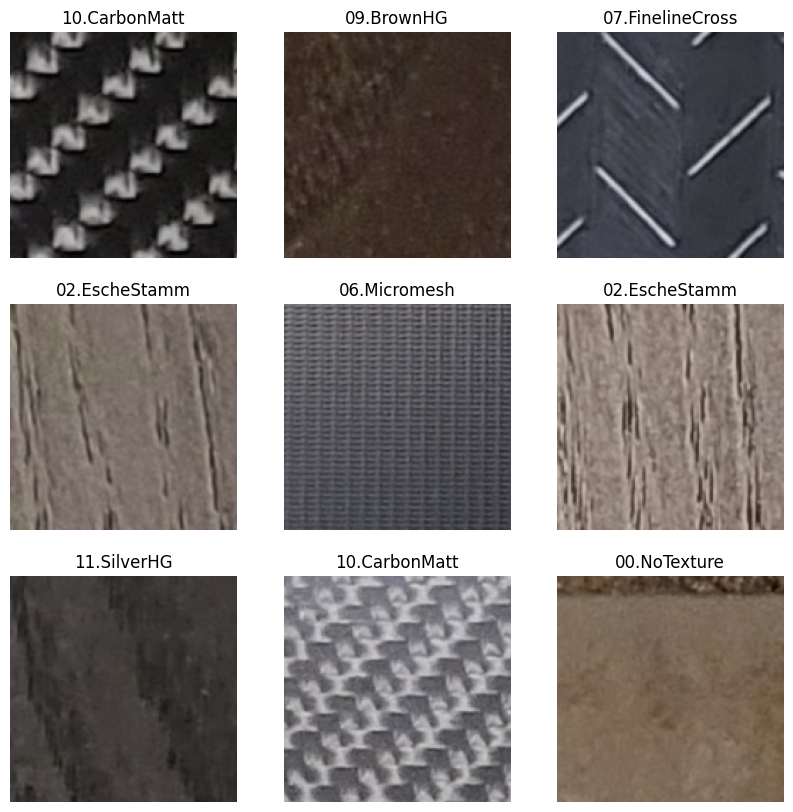

In [6]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [7]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)         # Primer 20%
validation_dataset = validation_dataset.skip(val_batches // 5)   # Resto 80%

In [8]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 20
Number of test batches: 4


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [10]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal_and_vertical'),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.1),
])

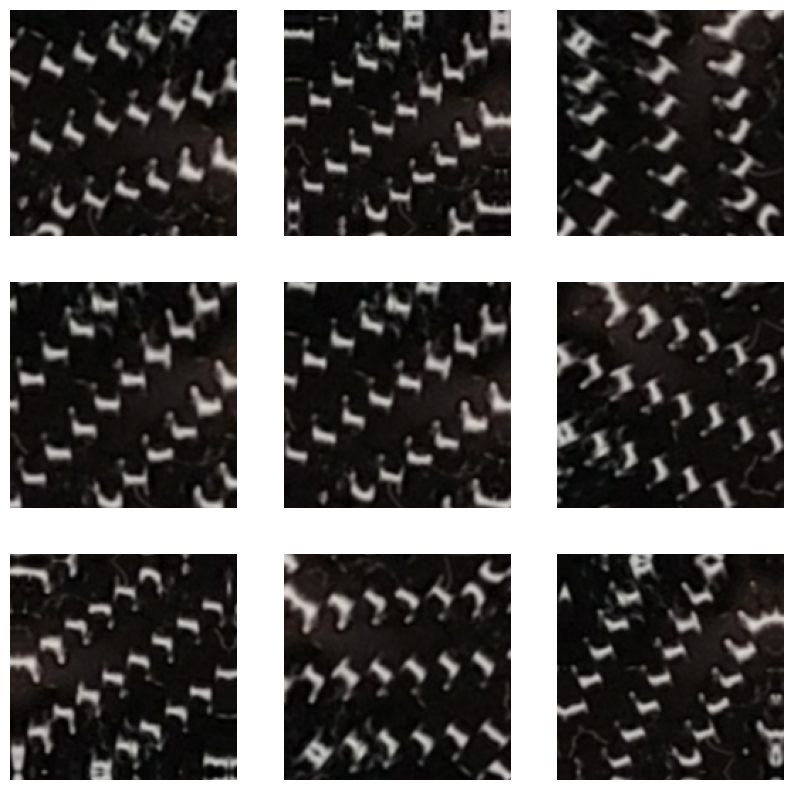

In [11]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [12]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [13]:
rescale = tf.keras.layers.Rescaling(1./255, offset=-1)

In [14]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE, include_top=False,alpha=0.75, weights='imagenet')

In [15]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


In [16]:
base_model.trainable = False

In [59]:
#base_model.summary()

In [17]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [18]:
num_classes = len(class_names)
print('Number of classes:', num_classes)

Number of classes: 15


In [19]:
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 15)


In [20]:
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # ← ¡Aquí está el cambio!
])

In [21]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # ← Multiclase
              metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_dataset,
                    validation_data=validation_dataset,
                    epochs=20,
                    callbacks=[early_stopping])

Epoch 1/20


95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 247ms/step - accuracy: 0.1002 - loss: 2.9079 - val_accuracy: 0.4058 - val_loss: 2.1302
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.3083 - loss: 2.2050 - val_accuracy: 0.4984 - val_loss: 1.7958
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 199ms/step - accuracy: 0.4065 - loss: 1.9154 - val_accuracy: 0.5081 - val_loss: 1.6030
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.4577 - loss: 1.7852 - val_accuracy: 0.5390 - val_loss: 1.4823
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.4935 - loss: 1.6251 - val_accuracy: 0.5666 - val_loss: 1.4068
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.5121 - loss: 1.5881 - val_accuracy: 0.5828 - val_loss: 1.3378
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.5483 - loss: 1.4764 - val_accuracy: 0.6006 - val_loss: 1.2547
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.5878 - loss: 1.4100 - val_accuracy: 0.599

In [22]:
for images, labels in train_dataset.take(1):
    print("Imágenes:", images.shape)
    print("Etiquetas:", labels.shape, labels[:5].numpy())


Imágenes: (32, 160, 160, 3)
Etiquetas: (32,) [14 10  3  1  3]


In [28]:
#model.summary()

In [23]:
len(model.trainable_variables)

4

In [24]:
initial_epochs = 20

loss0, accuracy0 = model.evaluate(validation_dataset)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.6503 - loss: 0.9977


In [25]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 1.00
initial accuracy: 0.65


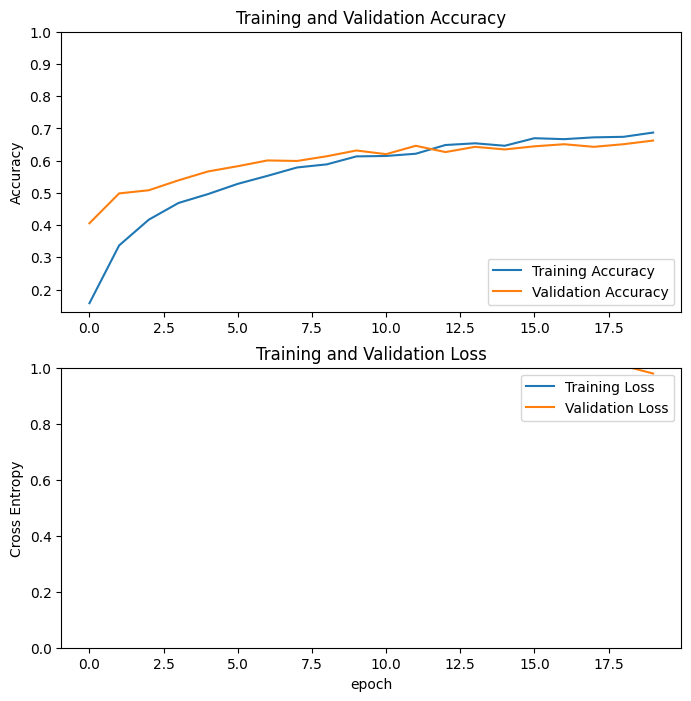

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [27]:
base_model.trainable = True

In [28]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [29]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # o from_logits=True si la última capa no tiene softmax
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate / 10),
    metrics=['accuracy']
)

In [74]:
#model.summary()

In [30]:
len(model.trainable_variables)

58

In [31]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset)

Epoch 20/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 296ms/step - accuracy: 0.1759 - loss: 4.0990 - val_accuracy: 0.5860 - val_loss: 1.2367
Epoch 21/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.2726 - loss: 2.9061 - val_accuracy: 0.5097 - val_loss: 1.5133
Epoch 22/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 268ms/step - accuracy: 0.3514 - loss: 2.2473 - val_accuracy: 0.4838 - val_loss: 1.6957
Epoch 23/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.4485 - loss: 1.8369 - val_accuracy: 0.4545 - val_loss: 1.8311
Epoch 24/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.4928 - loss: 1.5904 - val_accuracy: 0.4675 - val_loss: 1.8245
Epoch 25/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 26s 277ms/step - accuracy: 0.5245 - loss: 1.4524 - val_accuracy: 0.4854 - val_loss: 1.8047
Epoch 26/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.5689 - loss: 1.3338 - val_accuracy: 0.4789 - val_loss: 1.8677
Epoch 27/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step - accuracy: 0.5886 - loss: 1.2914 - 

In [32]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

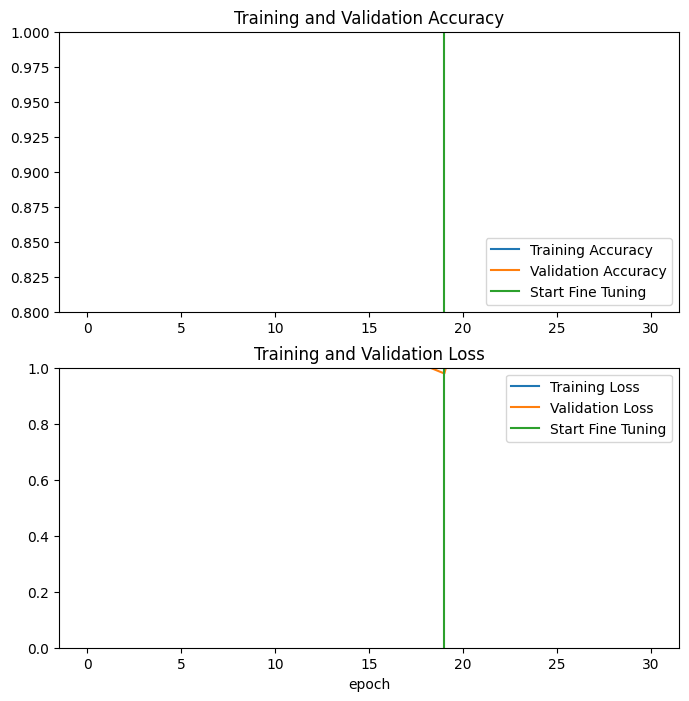

In [33]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [34]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5521 - loss: 1.4644
Test accuracy : 0.5390625


Aciertos: 19/32 (59.38%)
Fallas: 13/32 (40.62%)
Predicted class indices:
 [ 5  9  0  2  6 11  5  4  7  1  6  5  0  6  4  9  0 11  9  5  1  6  7  4
  5  5  4 14  5  1  4  7]
True labels:
 [ 7  8  2  2 12 11  6  4  7  2  3 12  0  6  4  9  0 11  9  7  1  1  7 10
  5  5 10 14  5  1 10  7]


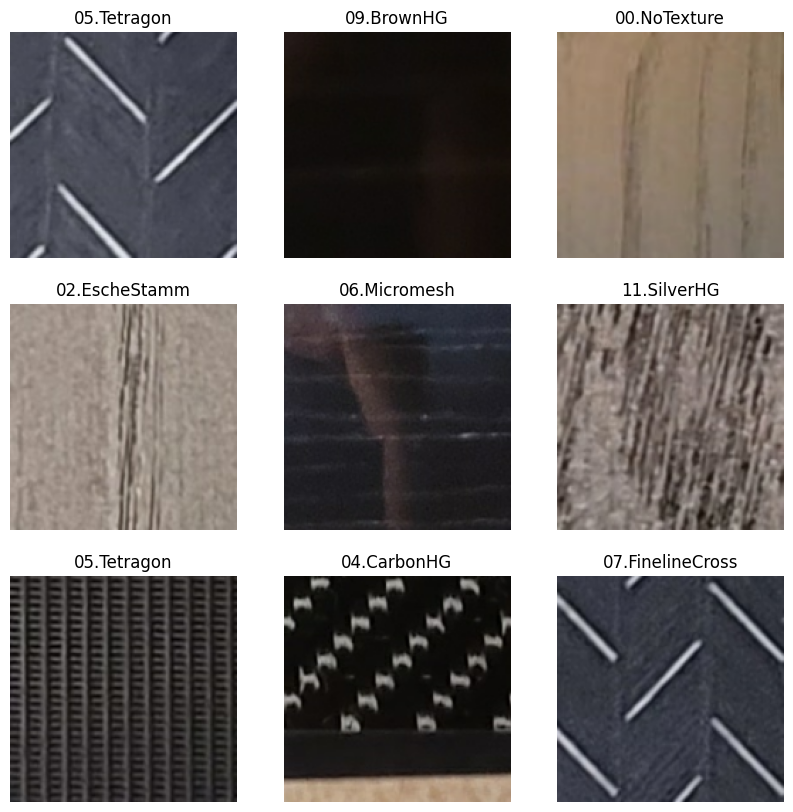

In [35]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

predictions = model.predict_on_batch(image_batch)

# Convertir a etiquetas predichas tomando la clase con mayor probabilidad
predicted_classes = tf.argmax(predictions, axis=1)

correct_predictions = tf.equal(predicted_classes, label_batch)
num_correct = tf.reduce_sum(tf.cast(correct_predictions, tf.int32)).numpy()
total = len(label_batch)
accuracy = num_correct / total
error_rate = 1 - accuracy

print(f"Aciertos: {num_correct}/{total} ({accuracy * 100:.2f}%)")
print(f"Fallas: {total - num_correct}/{total} ({error_rate * 100:.2f}%)")
print('Predicted class indices:\n', predicted_classes.numpy())
print('True labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predicted_classes[i]])
  plt.axis("off")